In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig5_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


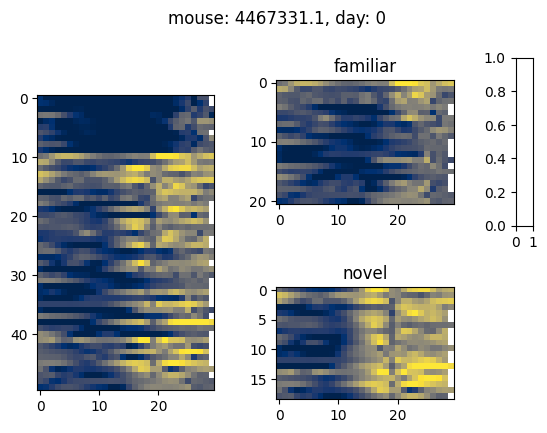

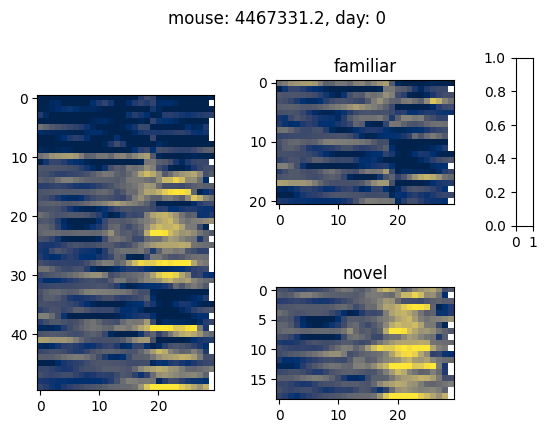

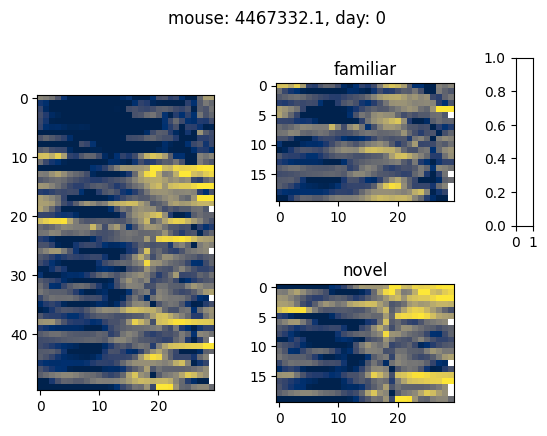

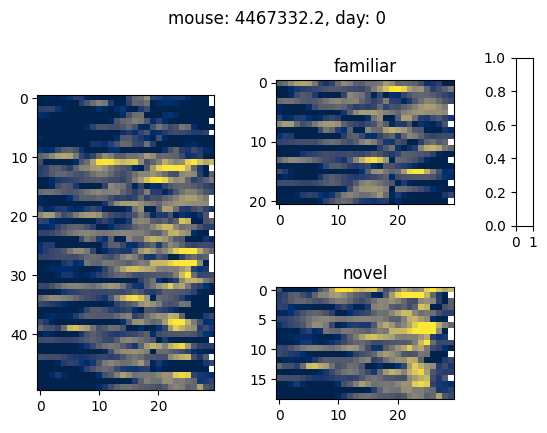

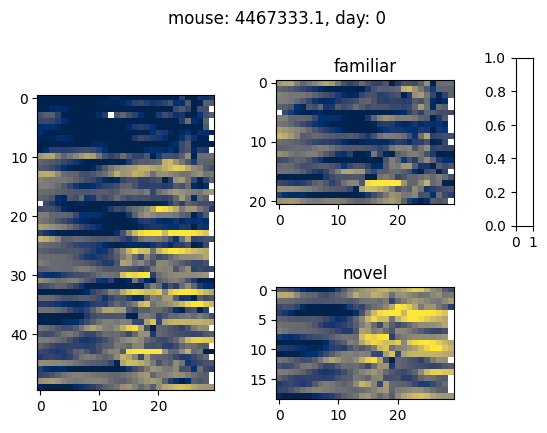

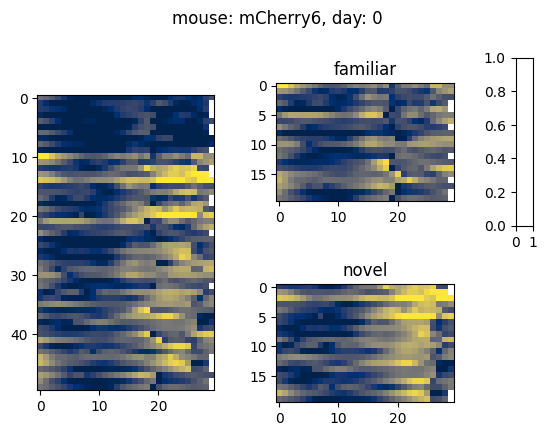

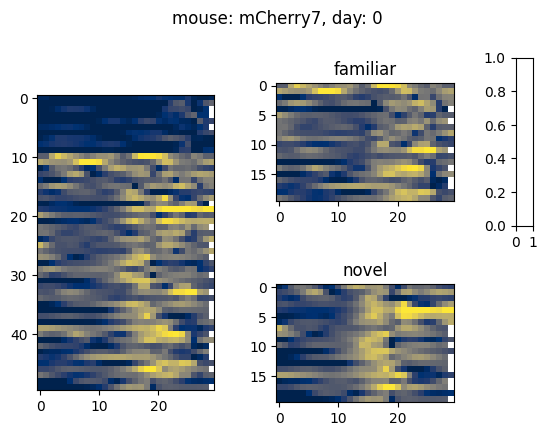

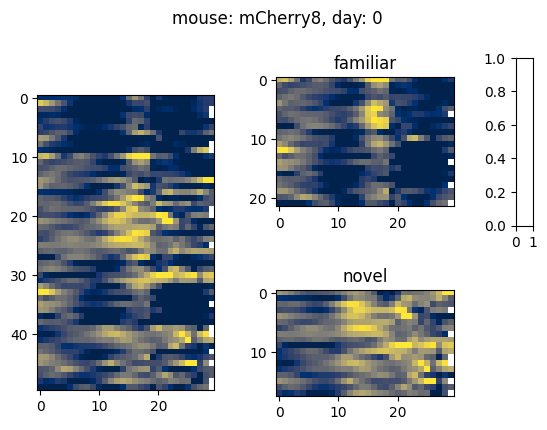

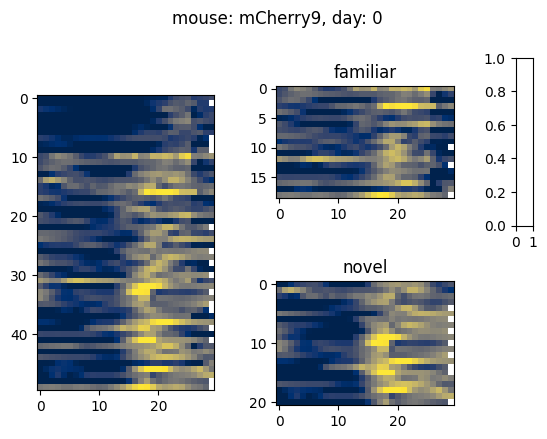

In [149]:
for mouse in ctrl_mice:
    block_rate.plot_single_session('ctrl', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

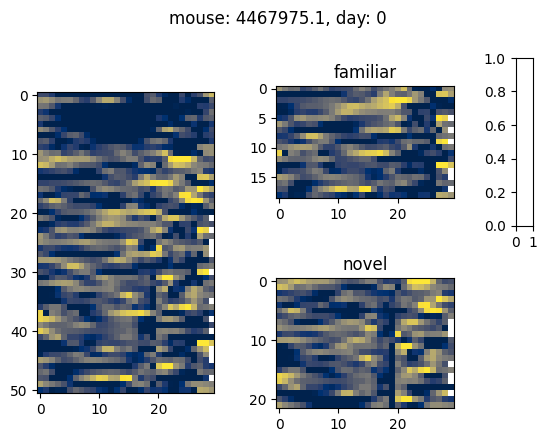

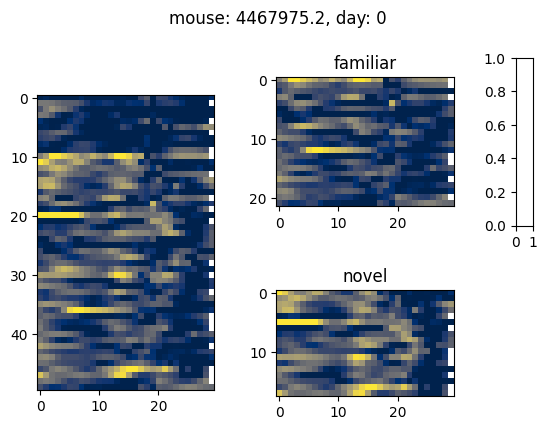

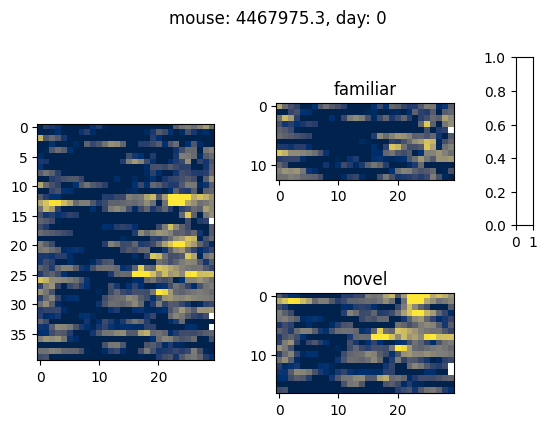

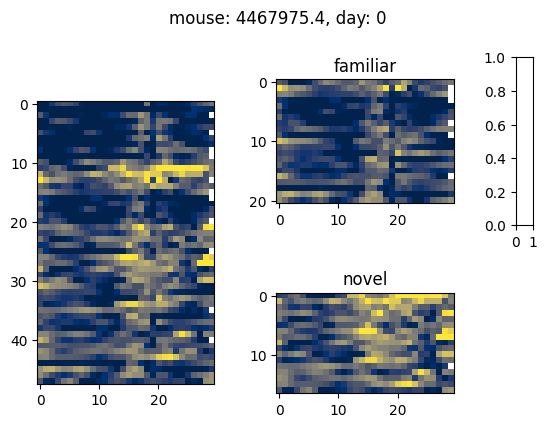

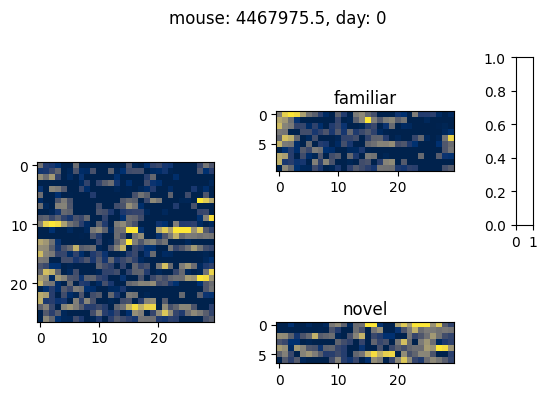

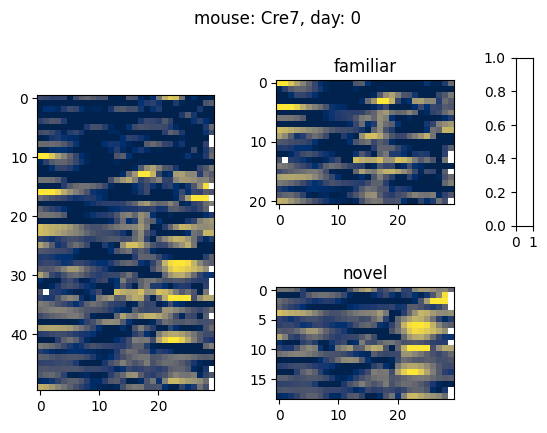

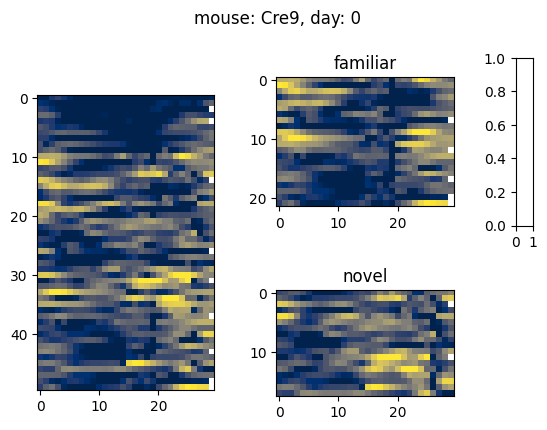

In [150]:
for mouse in ko_mice:
    block_rate.plot_single_session('ko', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

plot average activity, running speed and licks with no normalization

plot population normalized activity, speed and licks

linear model with activity or normalized activity

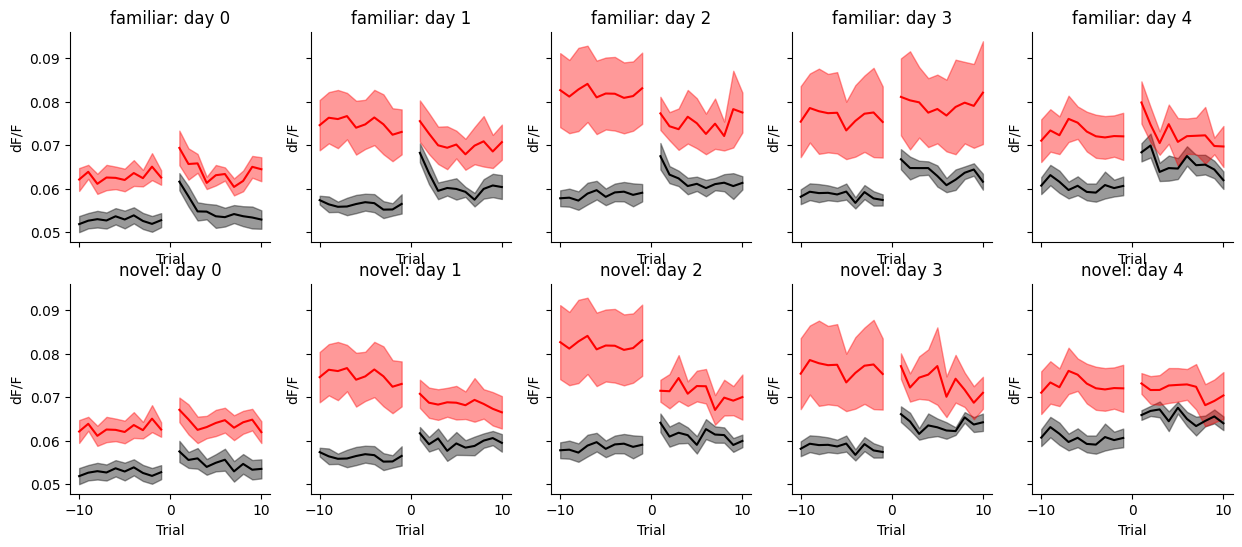

In [35]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('dF/F')
    a.set_xlabel('Trial')


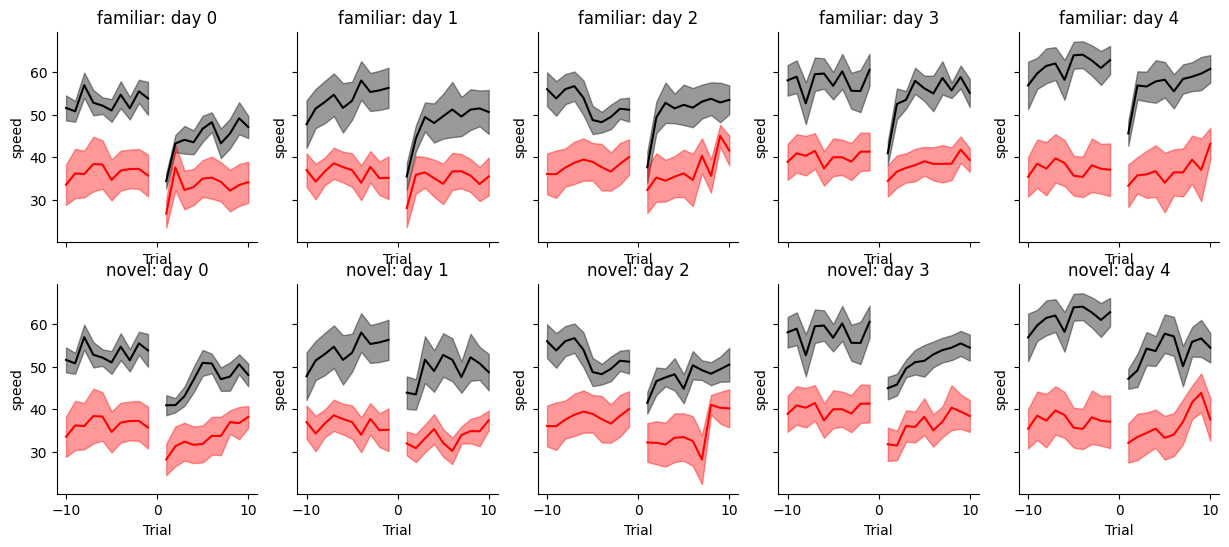

In [37]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(data['baseline_speed'],axis=1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(data['block_fam_speed'],axis=1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(data['block_nov_speed'],axis=1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('speed')
    a.set_xlabel('Trial')


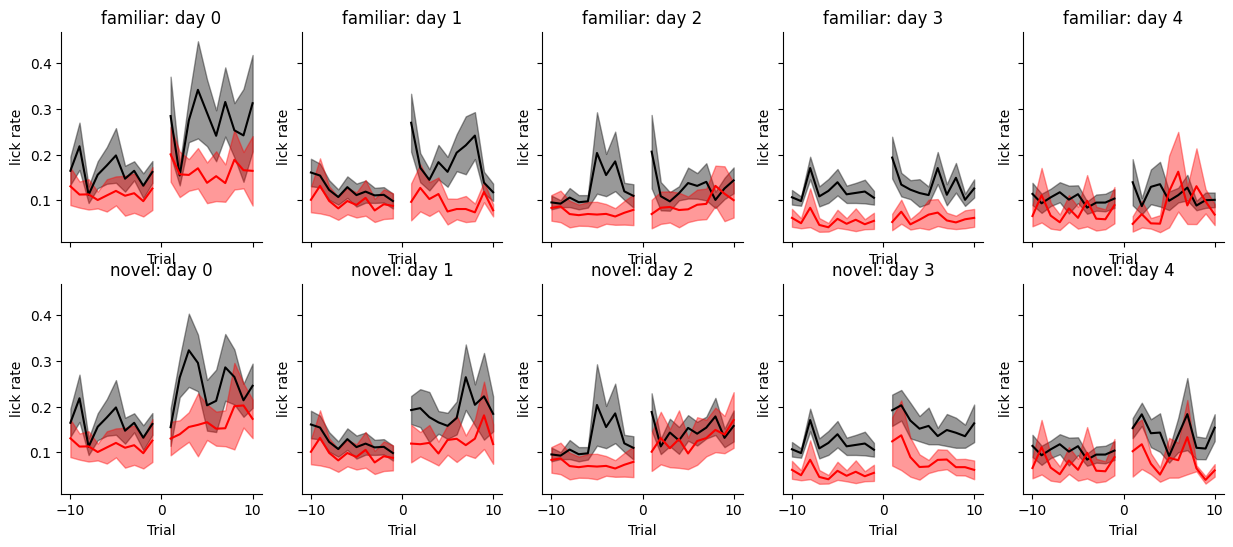

In [38]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(data['baseline_licks'],axis=1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(data['block_fam_licks'],axis=1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(data['block_nov_licks'],axis=1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('lick rate')
    a.set_xlabel('Trial')


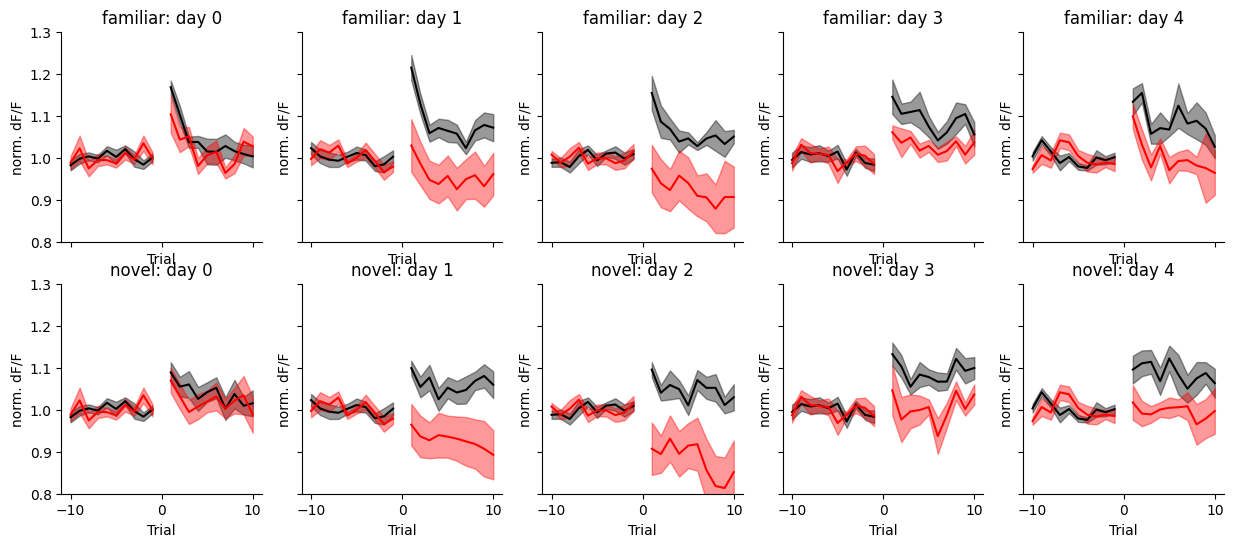

In [5]:
# plot average fluorescence, normalizing to baseline population activity
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base/_base.mean()

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]/_base.mean()
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]/_base.mean()
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('norm. dF/F')
    a.set_xlabel('Trial')
    a.set_ylim([.8,1.3])

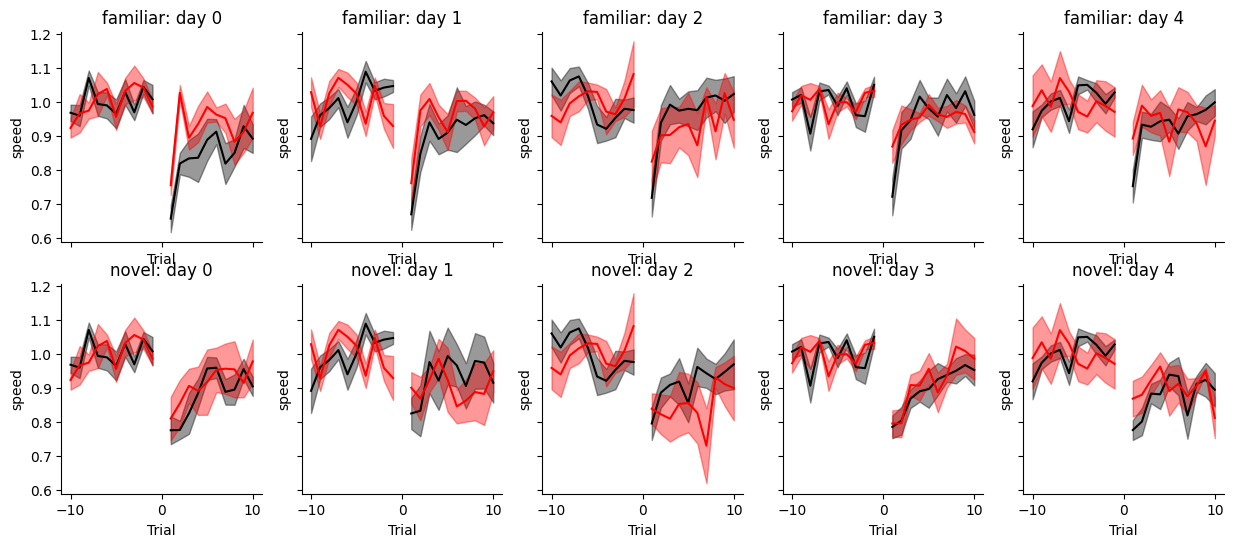

In [41]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(data['baseline_speed'],axis=1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base/_base.mean()

            _fam = np.nanmean(data['block_fam_speed'],axis=1)[:10]/_base.mean()
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(data['block_nov_speed'],axis=1)[:10]/_base.mean()
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('speed')
    a.set_xlabel('Trial')


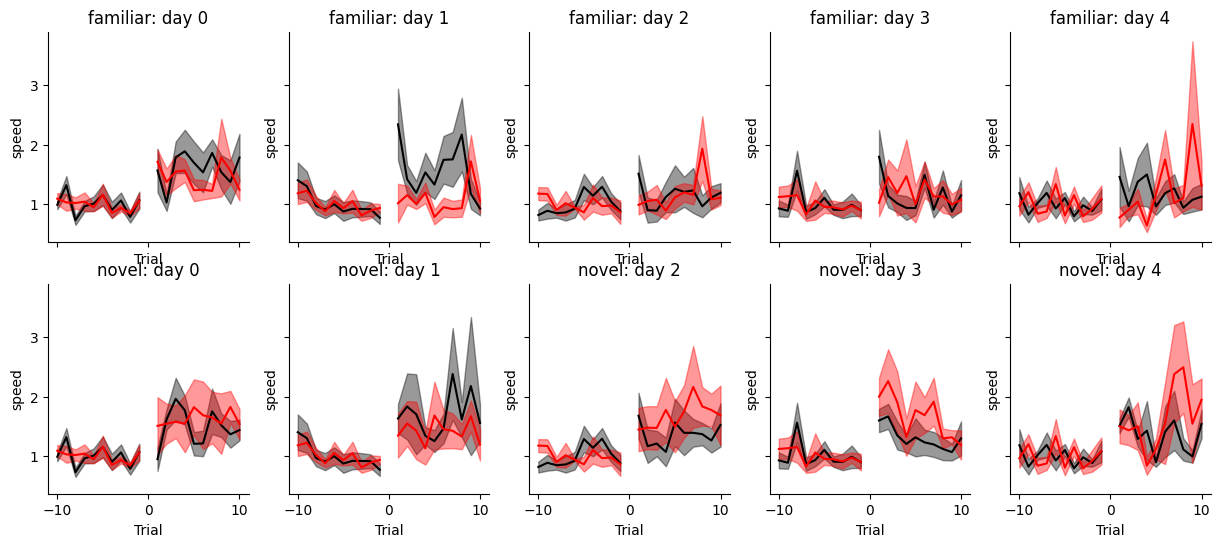

In [42]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(data['baseline_licks'],axis=1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base/_base.mean()

            _fam = np.nanmean(data['block_fam_licks'],axis=1)[:10]/_base.mean()
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(data['block_nov_licks'],axis=1)[:10]/_base.mean()
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('speed')
    a.set_xlabel('Trial')


In [48]:
df = block_rate.build_dataframe(max_trial=5, norm='population', norm_behavior=True)
df = df.loc[df['day']<5]

In [49]:
import statsmodels.formula.api as smf
df['condition'] = df['condition'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')

mdl = smf.mixedlm("novel_rate ~ condition + day + novel_speed + novel_licks  ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/811041458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition'] = df['condition'].astype('category')
/tmp/ipykernel_185757/811041458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/811041458.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:              MixedLM Dependent Variable: novel_rate
No. Observations:   80      Method:             REML      
No. Groups:         16      Scale:              0.0047    
Min. group size:    5       Log-Likelihood:     73.8232   
Max. group size:    5       Converged:          Yes       
Mean group size:    5.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        1.210    0.083 14.615 0.000  1.048  1.372
condition[T.ko] -0.093    0.026 -3.585 0.000 -0.143 -0.042
day[T.1]        -0.026    0.025 -1.071 0.284 -0.075  0.022
day[T.2]        -0.055    0.024 -2.247 0.025 -0.102 -0.007
day[T.3]         0.013    0.024  0.526 0.599 -0.035  0.060
day[T.4]         0.016    0.024  0.651 0.515 -0.032  0.064
novel_speed     -0.124    0.080 -1.549 0.121 -0.281  0.033
novel_licks     -0.014    0.015 -0.940 0.347 -0.043  0.015
Group Var        0.002    0.016                           
==========================================================

"""

In [40]:
df = block_rate.build_dataframe(max_trial=5)

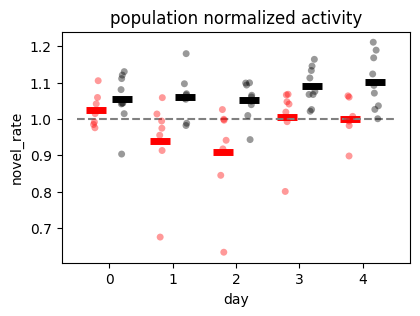

In [41]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=block_rate.df.loc[block_rate.df['day']<5,:],
            x='day',
            y='novel_rate',
            hue='condition', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            dodge=True,
            alpha=.4,
            ax=ax,
            legend=False)



sns.pointplot(data=block_rate.df.loc[block_rate.df['day']<5,:],
            x='day',
            y='novel_rate',
            errorbar=None,
            hue='condition',
            hue_order = ['ko', 'ctrl'],
            dodge = .4,
            palette = ['red','black'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')


In [42]:

res = pg.mixed_anova(data=block_rate.df.loc[block_rate.df['day']<5,:], dv='novel_rate', 
                     within='day', between='condition', subject='mouse')
print(res)

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  0.181406    1   14  0.181406  13.358410  0.002599  0.488274   
1          day  0.057492    4   56  0.014373   3.184916  0.019911  0.185332   
2  Interaction  0.028792    4   56  0.007198   1.595021  0.188360  0.102278   

        eps  
0       NaN  
1  0.605243  
2       NaN  


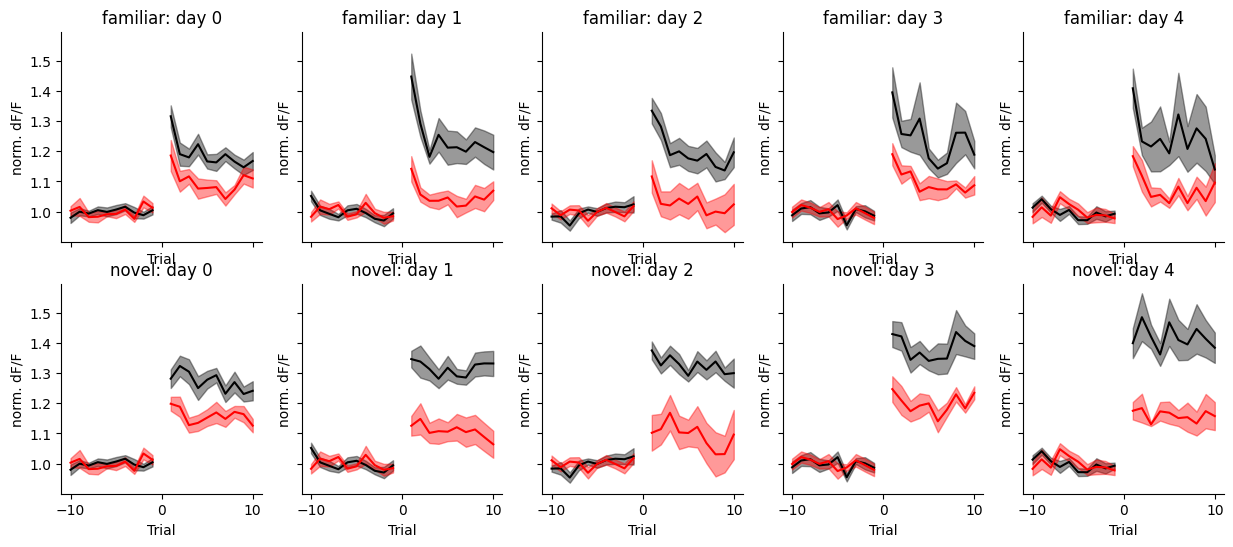

In [153]:
# plot average fluoresence, normalizing each cell to its baseline population activity
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            cell_denom = data['baseline_avg_act']
            _base = np.nanmean(np.nanmean(data['baseline_act']/cell_denom,axis=1),axis=-1)
           
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(np.nanmean(data['block_fam_act']/cell_denom,axis=1),axis=-1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act']/cell_denom,axis=1), axis=-1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('norm. dF/F')
    a.set_xlabel('Trial')

In [43]:
block_rate_sparse = stx.novel_activity_rate.BlockTransitionActivityRate_Sparse(ts_key='F_dff')

SparseKO_02
SparseKO_06
SparseKO_08


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_11
SparseKO_13


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:286: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.

SparseKO_09


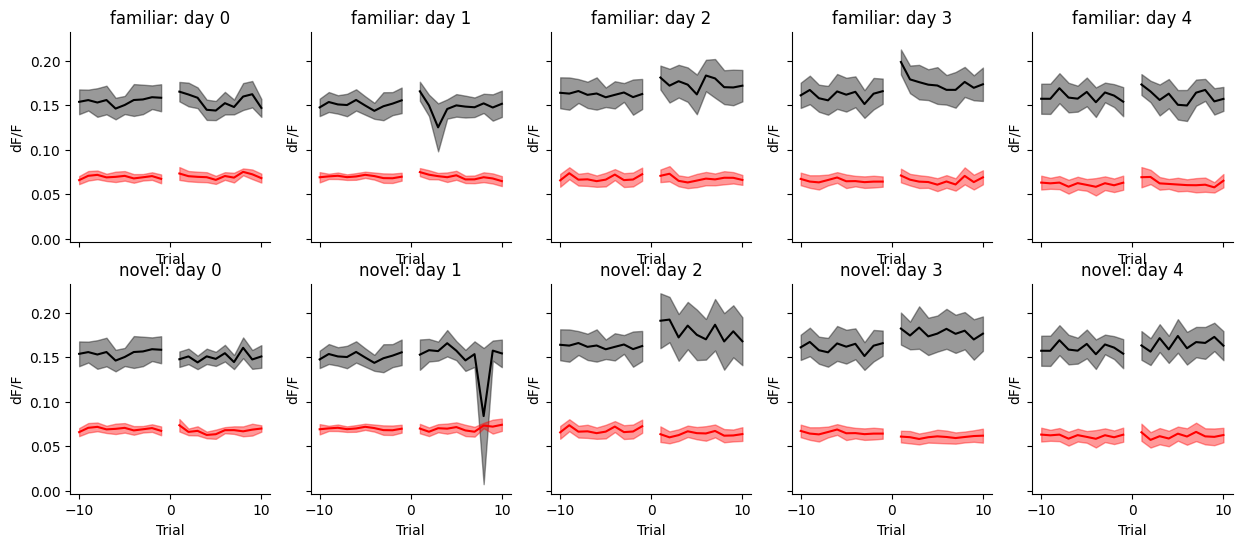

In [5]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
    fam = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
    nov = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}

    
    for i, mouse in enumerate(sparse_mice):
        for chan in ('channel_0', 'channel_1'):
            if mouse == 'SparseKO_09' and day ==2:
                    continue
            data = block_rate_sparse.activity_rates[mouse][day][chan]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[chan][i,:_base.shape[0]] = _base

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]
            fam[chan][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]
            nov[chan][i,:_nov.shape[0]] = _nov

    for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('dF/F')
    a.set_xlabel('Trial')

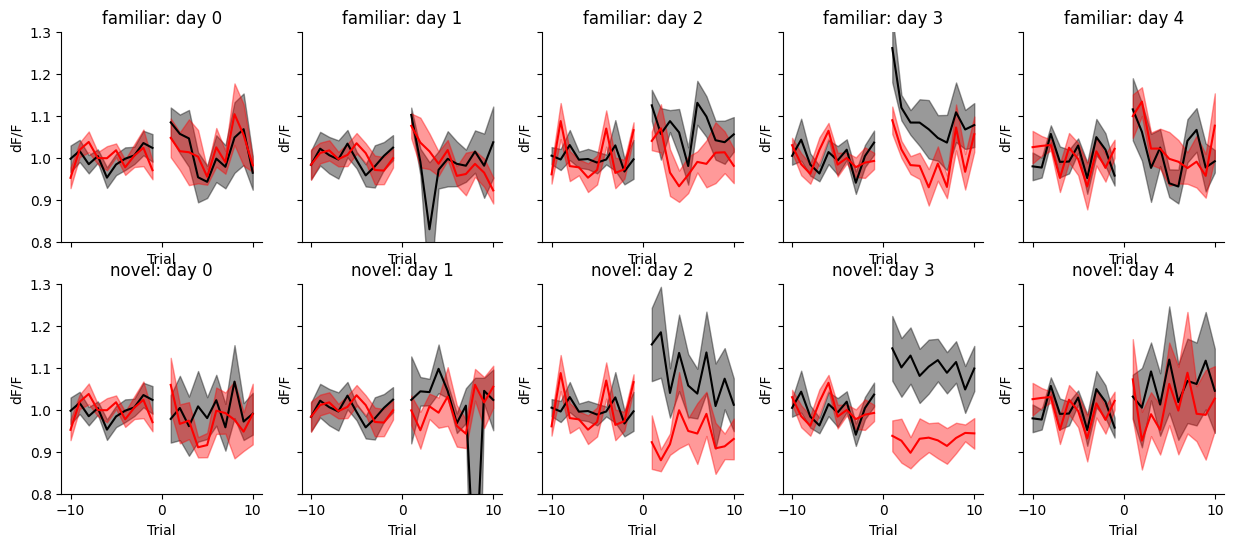

In [7]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
    fam = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
    nov = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}

    
    for i, mouse in enumerate(sparse_mice):
        for chan in ('channel_0', 'channel_1'):
            if mouse == 'SparseKO_09' and day ==2:
                    continue
            data = block_rate_sparse.activity_rates[mouse][day][chan]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[chan][i,:_base.shape[0]] = _base/_base.mean()

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]/_base.mean()
            fam[chan][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]/_base.mean()
            nov[chan][i,:_nov.shape[0]] = _nov

    for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('dF/F')
    a.set_xlabel('Trial')
    a.set_ylim([.8,1.3])

In [53]:
df = block_rate_sparse.build_dataframe(max_trial=5)
df = df.loc[df['day']<5]

In [58]:
df['channel'] = df['channel'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')

mdl = smf.mixedlm("novel_rate ~ channel + day", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/1191039309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['channel'] = df['channel'].astype('category')
/tmp/ipykernel_185757/1191039309.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/1191039309.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM   Dependent Variable:   novel_rate
No. Observations:   68        Method:               REML      
No. Groups:         7         Scale:                0.0164    
Min. group size:    8         Log-Likelihood:       28.4392   
Max. group size:    10        Converged:            Yes       
Mean group size:    9.7                                       
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.928    0.043 21.561 0.000  0.843  1.012
channel[T.channel_1] 0.096    0.031  3.103 0.002  0.035  0.157
day[T.1]             0.048    0.048  0.984 0.325 -0.047  0.142
day[T.2]             0.050    0.051  0.996 0.319 -0.049  0.150
day[T.3]             0.043    0.048  0.884 0.377 -0.052  0.138
day[T.4]             0.050    0.048  1.041 0.298 -0.044  0.145
Group Var            0.003    0.022                           
==============================================================

"""

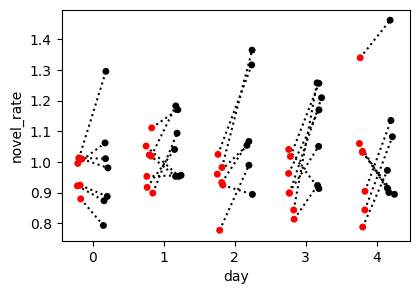

In [ ]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=block_rate_sparse.df.loc[block_rate_sparse.df['day']<5,:],
            x='day',
            y='novel_rate',
            hue='channel', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


In [17]:
res = pg.rm_anova(data=block_rate_sparse.df.loc[block_rate_sparse.df['day']<5,:],
                  dv='novel_rate', 
                  within=['day', 'channel'],subject='mouse')
print(res)

          Source        SS  ddof1  ddof2        MS         F     p-unc  \
0            day  0.038097      4     20  0.009524  0.412227  0.797740   
1        channel  0.150637      1      5  0.150637  8.221915  0.035102   
2  day * channel  0.070857      4     20  0.017714  1.726188  0.183754   

   p-GG-corr       ng2       eps  
0   0.634196  0.035542  0.403885  
1   0.035102  0.127179  1.000000  
2   0.220079  0.064144  0.575904  


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [25]:
pt = pg.pairwise_tests(data=block_rate_sparse.df.loc[block_rate_sparse.df['day']<5,:],
                        dv='novel_rate',
                        within=['day','channel'],
                        subject='mouse',
                          )
print(pt.iloc[11:20])

         Contrast day          A          B Paired Parametric         T  dof  \
11  day * channel   0  channel_0  channel_1   True       True -0.242711  5.0   
12  day * channel   1  channel_0  channel_1   True       True -0.858132  5.0   
13  day * channel   2  channel_0  channel_1   True       True -3.007601  5.0   
14  day * channel   3  channel_0  channel_1   True       True -2.339827  5.0   
15  day * channel   4  channel_0  channel_1   True       True -1.235587  5.0   

   alternative     p-unc   BF10    hedges  
11   two-sided  0.817871  0.383 -0.094181  
12   two-sided  0.430025  0.498 -0.411514  
13   two-sided  0.029838  3.051 -1.152736  
14   two-sided  0.066394  1.701 -1.371505  
15   two-sided  0.271496  0.651 -0.391243  
